#Import modules

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

#Data

In [3]:
rna = pd.read_csv('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/TCGA_Pan_rna_combination.csv', index_col = 0)
rna

,ENSG00000211592,ENSG00000164930,ENSG00000197594,ENSG00000124226,ENSG00000159184,ENSG00000198668,ENSG00000179142,ENSG00000007350,ENSG00000129744,ENSG00000170035,...,ENSG00000034677,ENSG00000135241,ENSG00000083123,ENSG00000136247,ENSG00000095303,ENSG00000130717,ENSG00000122643,ENSG00000141959,ENSG00000184307,ENSG00000115425
TCGA-D8-A146-01A-31R-A115-07,7654.8063,40.8331,48.1403,81.6687,0.0868,174.3412,0.0,0.0748,0.7642,31.8422,...,58.7566,42.2553,24.4281,30.9430,19.7246,52.3589,26.8390,68.9754,5.9405,8.6663
TCGA-AQ-A0Y5-01A-11R-A14M-07,10.8013,53.8007,46.3698,45.5170,2.3900,223.5212,0.0,0.0000,0.1269,27.1147,...,31.5056,35.0713,23.7728,26.4577,19.7589,27.6158,24.1808,79.0960,5.6007,6.4292
TCGA-C8-A274-01A-11R-A16F-07,216.4474,10.6594,86.4358,91.8483,15.0755,179.7067,0.0,0.0261,1.0661,43.3071,...,60.3827,26.8141,22.2365,11.0825,10.2192,40.1886,17.6016,52.4967,12.0377,23.0999
TCGA-BH-A0BD-01A-11R-A034-07,6638.7969,75.4110,26.4862,80.8786,0.0574,148.2575,0.0,0.2145,0.0793,19.6837,...,65.0513,21.8482,18.0531,33.7493,25.0809,49.3229,44.9333,68.2362,2.5353,11.0700
TCGA-B6-A1KC-01B-11R-A157-07,74.1970,60.7607,25.3311,44.0269,0.0527,126.7572,0.0,0.0113,0.0273,6.2819,...,43.9291,26.5714,13.9050,32.1099,12.0555,13.6978,21.4567,11.6663,8.5637,13.8316
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-CV-7432-01A-11R-2132-07,200.9838,67.9835,0.2935,48.1936,0.0000,159.0549,0.0,0.0000,0.0000,85.3942,...,15.9360,22.5147,7.8301,7.8763,78.3379,26.2185,34.0619,78.5287,5.6092,0.3106
TCGA-IQ-7630-01A-11R-2081-07,139.9574,105.8413,1.3258,73.7803,0.0000,180.6264,0.0,0.0788,0.0000,57.3098,...,30.9696,24.4337,4.6202,20.5524,109.4675,17.2952,35.2165,90.9530,2.4663,4.8415
TCGA-H7-A6C4-11A-21R-A466-07,268.1355,8.7504,0.8797,16.8386,0.0173,80.2792,0.0,0.5654,6.6518,37.5042,...,10.5967,14.2603,3.7888,7.8909,14.6034,15.3442,24.5500,19.4137,0.3307,1.7400
TCGA-H7-8501-01A-11R-2403-07,5129.2628,105.6087,0.9399,131.9729,0.0000,176.0677,0.0,0.0838,0.0000,72.6890,...,32.5125,24.1074,5.7361,18.5594,24.5816,38.2891,62.9143,48.6804,2.3742,11.0678


In [4]:
drop_cols = []
for i in rna.columns:
  if i.endswith('.1'):
    drop_cols.append(i)
    print(i)

ENSG00000142182.1
ENSG00000166228.1
ENSG00000100292.1
ENSG00000177889.1
ENSG00000178685.1
ENSG00000088305.1
ENSG00000143799.1
ENSG00000181222.1
ENSG00000074800.1
ENSG00000187555.1
ENSG00000166349.1
ENSG00000090661.1
ENSG00000165672.1
ENSG00000143418.1
ENSG00000121691.1
ENSG00000005075.1
ENSG00000204227.1
ENSG00000175592.1
ENSG00000176170.1
ENSG00000138061.1
ENSG00000177700.1
ENSG00000114166.1
ENSG00000099817.1
ENSG00000162407.1
ENSG00000078140.1
ENSG00000124212.1
ENSG00000147669.1
ENSG00000135679.1
ENSG00000047315.1
ENSG00000179115.1
ENSG00000104907.1
ENSG00000091138.1
ENSG00000170890.1
ENSG00000138772.1
ENSG00000115350.1
ENSG00000068903.1
ENSG00000100644.1
ENSG00000133606.1
ENSG00000148229.1
ENSG00000108773.1
ENSG00000163659.1
ENSG00000135218.1
ENSG00000116761.1


In [5]:
rna = rna.drop(columns = drop_cols)
for i in rna.columns:
  if i.endswith('.1'):
    print(i)

In [6]:
rna.head(3)

,ENSG00000211592,ENSG00000164930,ENSG00000197594,ENSG00000124226,ENSG00000159184,ENSG00000198668,ENSG00000179142,ENSG00000007350,ENSG00000129744,ENSG00000170035,...,ENSG00000034677,ENSG00000135241,ENSG00000083123,ENSG00000136247,ENSG00000095303,ENSG00000130717,ENSG00000122643,ENSG00000141959,ENSG00000184307,ENSG00000115425
TCGA-D8-A146-01A-31R-A115-07,7654.8063,40.8331,48.1403,81.6687,0.0868,174.3412,0.0,0.0748,0.7642,31.8422,...,58.7566,42.2553,24.4281,30.9430,19.7246,52.3589,26.8390,68.9754,5.9405,8.6663
TCGA-AQ-A0Y5-01A-11R-A14M-07,10.8013,53.8007,46.3698,45.5170,2.3900,223.5212,0.0,0.0000,0.1269,27.1147,...,31.5056,35.0713,23.7728,26.4577,19.7589,27.6158,24.1808,79.0960,5.6007,6.4292
TCGA-C8-A274-01A-11R-A16F-07,216.4474,10.6594,86.4358,91.8483,15.0755,179.7067,0.0,0.0261,1.0661,43.3071,...,60.3827,26.8141,22.2365,11.0825,10.2192,40.1886,17.6016,52.4967,12.0377,23.0999


#Log2 transformation

In [7]:
rna = rna.apply(lambda x: np.log2(x + 1))
rna.head(3)

,ENSG00000211592,ENSG00000164930,ENSG00000197594,ENSG00000124226,ENSG00000159184,ENSG00000198668,ENSG00000179142,ENSG00000007350,ENSG00000129744,ENSG00000170035,...,ENSG00000034677,ENSG00000135241,ENSG00000083123,ENSG00000136247,ENSG00000095303,ENSG00000130717,ENSG00000122643,ENSG00000141959,ENSG00000184307,ENSG00000115425
TCGA-D8-A146-01A-31R-A115-07,12.902339,5.386573,5.618835,6.369269,0.120086,7.454021,0.0,0.104068,0.819014,5.037479,...,5.901026,5.434805,4.668352,4.997428,4.373272,5.737657,4.799035,6.128776,2.795040,3.272964
TCGA-AQ-A0Y5-01A-11R-A14M-07,3.560874,5.776122,5.565896,5.539686,1.761285,7.810708,0.0,0.000000,0.172359,4.813253,...,5.022616,5.172780,4.630685,4.779139,4.375658,4.838740,4.654252,6.323658,2.722619,2.893207
TCGA-C8-A274-01A-11R-A16F-07,7.764523,3.543422,6.450152,6.536804,4.006792,7.497506,0.0,0.037171,1.046910,5.469466,...,5.939760,4.797745,4.538321,3.594847,3.487898,5.364173,4.217355,5.741378,3.704617,4.590955


#Data shuffling

In [8]:
shuffled_data = rna.sample(frac=1, random_state=0)
shuffled_rna = shuffled_data[rna.columns]
rna = shuffled_rna
rna.head(3)

,ENSG00000211592,ENSG00000164930,ENSG00000197594,ENSG00000124226,ENSG00000159184,ENSG00000198668,ENSG00000179142,ENSG00000007350,ENSG00000129744,ENSG00000170035,...,ENSG00000034677,ENSG00000135241,ENSG00000083123,ENSG00000136247,ENSG00000095303,ENSG00000130717,ENSG00000122643,ENSG00000141959,ENSG00000184307,ENSG00000115425
TCGA-D1-A17S-01A-11R-A12I-07,7.589774,3.345709,0.481712,4.534666,0.000000,5.658174,0.000000,0.076696,0.000000,4.716129,...,3.368587,2.692628,1.520246,2.499706,3.788425,5.890646,3.132708,6.084617,2.002847,1.971663
TCGA-24-1564-01A-01R-1566-13,9.752921,6.498479,3.449812,6.677873,0.226509,7.172454,0.028003,6.415730,0.000000,6.435250,...,5.678080,4.006181,4.744559,5.727588,7.458881,4.946693,4.768565,6.915480,2.572017,4.190836
TCGA-BR-6456-01A-11R-1802-13,13.203806,5.382297,3.728933,6.993592,2.742308,7.939673,0.000000,0.061154,0.230695,5.442592,...,5.204939,4.958564,2.916075,4.692444,4.574834,5.307035,5.834261,7.716247,3.484306,3.776294


#Data imputation and normalization [-1, 1]

In [9]:
from sklearn.impute import SimpleImputer

def impute_normalize(df):
  data = df.copy()
  imputer = SimpleImputer(strategy='median')
  data = imputer.fit_transform(data)
  min_val = np.min(data)
  max_val = np.max(data)
  data_scaled = 2 * ((data - min_val) / (max_val - min_val)) - 1
  data_scaled = data_scaled.astype(np.float32)
  print('min:', np.min(data_scaled))
  print('max:', np.max(data_scaled))
  print('shape:', data_scaled.shape)

  return data_scaled

#Neural network

In [10]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [11]:
X = rna.drop(labels = ['ENSG00000211592'], axis = 'columns')
y = rna[['ENSG00000211592']]

In [12]:
input_features = X.columns.tolist()
input_features

['ENSG00000164930',
 'ENSG00000197594',
 'ENSG00000124226',
 'ENSG00000159184',
 'ENSG00000198668',
 'ENSG00000179142',
 'ENSG00000007350',
 'ENSG00000129744',
 'ENSG00000170035',
 'ENSG00000170950',
 'ENSG00000167815',
 'ENSG00000146151',
 'ENSG00000145384',
 'ENSG00000102226',
 'ENSG00000109452',
 'ENSG00000100121',
 'ENSG00000163558',
 'ENSG00000135111',
 'ENSG00000110887',
 'ENSG00000111206',
 'ENSG00000078295',
 'ENSG00000077044',
 'ENSG00000172534',
 'ENSG00000156795',
 'ENSG00000165195',
 'ENSG00000176383',
 'ENSG00000170142',
 'ENSG00000132330',
 'ENSG00000123453',
 'ENSG00000165030',
 'ENSG00000124615',
 'ENSG00000143207',
 'ENSG00000142657',
 'ENSG00000164405',
 'ENSG00000099810',
 'ENSG00000157326',
 'ENSG00000110066',
 'ENSG00000163218',
 'ENSG00000109332',
 'ENSG00000165475',
 'ENSG00000056998',
 'ENSG00000135363',
 'ENSG00000277893',
 'ENSG00000149313',
 'ENSG00000100889',
 'ENSG00000180818',
 'ENSG00000012779',
 'ENSG00000174233',
 'ENSG00000134824',
 'ENSG00000105939',


In [13]:
import pickle

with open('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/models/ENSG00000211592_combination_nn_model_input_features.pkl', 'wb') as f:
  pickle.dump(input_features, f)

In [14]:
X = X.values
y = y.values

In [15]:
print(X.shape)
print(y.shape)

(10668, 3493)
(10668, 1)


In [16]:
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size = 0.1, random_state = 0)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size = 0.5, random_state = 0)

X_train = impute_normalize(X_train)
X_test = impute_normalize(X_test)
X_val = impute_normalize(X_val)
y_train = impute_normalize(y_train)
y_test = impute_normalize(y_test)
y_val = impute_normalize(y_val)

print('Train data:')
print(X_train.shape)
print(y_train.shape)

print('Test data:')
print(X_test.shape)
print(y_test.shape)

print('Val data:')
print(X_val.shape)
print(y_val.shape)

min: -1.0
max: 1.0
shape: (9601, 3493)
min: -1.0
max: 1.0
shape: (533, 3493)
min: -1.0
max: 1.0
shape: (534, 3493)
min: -1.0
max: 1.0
shape: (9601, 1)
min: -1.0
max: 1.0
shape: (533, 1)
min: -1.0
max: 1.0
shape: (534, 1)
Train data:
(9601, 3493)
(9601, 1)
Test data:
(533, 3493)
(533, 1)
Val data:
(534, 3493)
(534, 1)


In [17]:
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Dropout


model = keras.Sequential([
    layers.Input(shape = (X_train.shape[1],)),
    layers.Dense(1024, activation = 'relu'),
    BatchNormalization(),
    Dropout(0.5),

    layers.Dense(512, activation = 'relu'),
    BatchNormalization(),
    Dropout(0.5),

    layers.Dense(256, activation = 'relu'),
    BatchNormalization(),
    Dropout(0.5),

    keras.layers.Dense(1, activation='linear')
])

In [18]:
model.compile(optimizer='adam',
              loss='mse',
              metrics=['mae'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1024)           │     3,577,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,241,409 (16.18 MB)

 Trainable params: 4,237,825 (16.17 MB)

 Non-trainable params: 3,584 (14.00 KB)

In [19]:
history = model.fit(X_train, y_train,
                    epochs=1000,
                    batch_size=32,
                    validation_data=(X_val, y_val),
                    shuffle = True,
                    callbacks=[tf.keras.callbacks.EarlyStopping(patience=100, restore_best_weights=True)]
                    )

Epoch 1/1000
301/301 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 2.1985 - mae: 1.1089 - val_loss: 0.1059 - val_mae: 0.2693
Epoch 2/1000
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3302 - mae: 0.4345 - val_loss: 0.0694 - val_mae: 0.2064
Epoch 3/1000
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1140 - mae: 0.2655 - val_loss: 0.0621 - val_mae: 0.1967
Epoch 4/1000
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0767 - mae: 0.2200 - val_loss: 0.0556 - val_mae: 0.1862
Epoch 5/1000
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0694 - mae: 0.2076 - val_loss: 0.0614 - val_mae: 0.1970
Epoch 6/1000
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0613 - mae: 0.1933 - val_loss: 0.0387 - val_mae: 0.1565
Epoch 7/1000
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0515 - mae: 0.1761 - val_loss: 0.0373 - val_mae: 0.1494
Epoch 8/1000
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0480 - mae: 0.1710 - val_loss: 0.0439 - val_mae: 0.1665
Epoch 9/1000
301/301 ━━━━━━━━━━━━━━━━━━

In [20]:
model.save('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/models/ENSG00000211592_combination_nn_model.keras')

In [21]:
loss, mae = model.evaluate(X_test, y_test, verbose=1)
print("Mean Absolute Error:", mae)

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0245 - mae: 0.1199
Mean Absolute Error: 0.12194987386465073


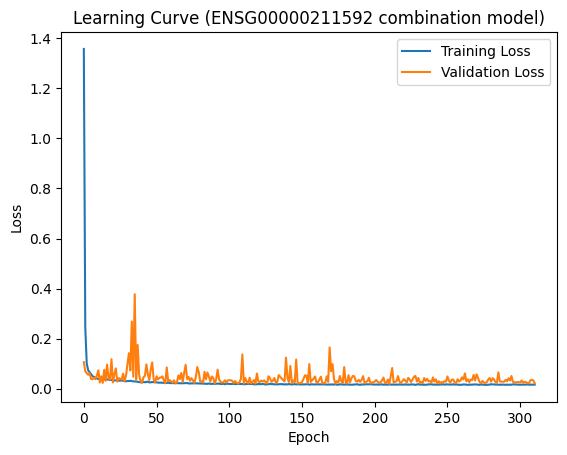

In [22]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Learning Curve (ENSG00000211592 combination model)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/ENSG00000211592_combination_learning_curve.svg', bbox_inches = 'tight')
plt.show()

In [23]:
train_loss = history.history['loss'][-1]
train_mae = history.history['mae'][-1]
print(f"Training Loss: {train_loss:.4f}")
print(f"Training MAE: {train_mae:.4f}")

Training Loss: 0.0162
Training MAE: 0.0997


In [24]:
val_loss = history.history['val_loss'][-1]
val_mae = history.history['val_mae'][-1]
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation MAE: {val_mae:.4f}")

Validation Loss: 0.0220
Validation MAE: 0.1121


In [25]:
loss, mae = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test MAE: {mae:.4f}")

Test Loss: 0.0258
Test MAE: 0.1219


In [26]:
predictions = model.predict(X_test)

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


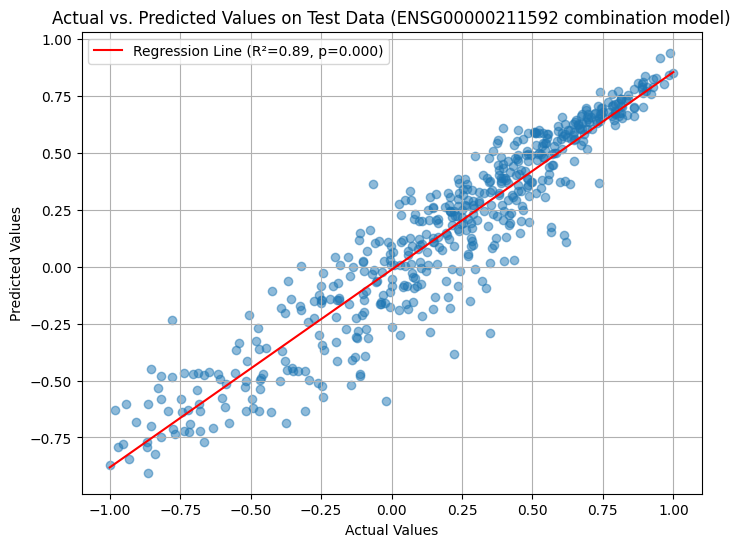

R-squared: 0.8866
P-value: 0.0000


In [27]:
from scipy.stats import linregress
import matplotlib.pyplot as plt
import numpy as np

# Calculate the regression line and statistics
slope, intercept, r_value, p_value, std_err = linregress(y_test.flatten(), predictions.flatten())

plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.5)

x_values = np.array([y_test.min(), y_test.max()])
plt.plot(x_values, intercept + slope * x_values, color='red', label=f'Regression Line (R²={r_value**2:.2f}, p={p_value:.3f})')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values on Test Data (ENSG00000211592 combination model)")
plt.grid(True)
plt.legend()
plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/ENSG00000211592_combination_Reg_plot_actual_pred_.svg', bbox_inches = 'tight')
plt.show()

print(f"R-squared: {r_value**2:.4f}")
print(f"P-value: {p_value:.4f}")